## Problem Type

This is a **supervised learning, binary classification** problem.

- **Supervised:** each patient already has a known diagnosis, so the model learns from labeled examples.
- **Classification:** the model predicts a category (malignant or benign), not a number.
- **Binary:** there are only two classes: 1 = malignant, 0 = benign.

**Goal:** use 30 measurements of cell nuclei from a breast tissue sample to predict whether a tumor is malignant or benign.

# Breast Cancer Diagnosis with Machine Learning

**Libraries used:**
- `pandas` (`pd`): loads and works with tables of data (DataFrames)
- `numpy` (`np`): fast math on arrays of numbers
- `matplotlib.pyplot` (`plt`): basic plotting
- `seaborn` (`sns`): nicer statistical plots built on matplotlib
- `sklearn` (scikit-learn): the machine learning library
  - `train_test_split`: splits data into training and testing sets
  - `StandardScaler`: puts all features on the same scale
  - `LogisticRegression`, `RandomForestClassifier`: the models
  - `accuracy_score`, `recall_score`, `classification_report`, `ConfusionMatrixDisplay`: measure how well the models do

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Used for stat plots
import seaborn as sns

# used for machine learning: Splitting, scaling, models, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, classification_report, ConfusionMatrixDisplay




## 1. Load the Data

The file `wdbc.data` has **no header row**, so the column names are created manually.

**Variables:**
- `features`: the 10 nucleus measurements (radius, texture, perimeter, etc.)
- `columns`: the full list of 32 column names: `id`, `diagnosis`, then each feature 3 times:
  - `_avg`: average value across all cells in the image
  - `_variation`: standard error, or how much the cells vary
  - `_largest`: average of the 3 largest values, the most abnormal cells
- `df`: the DataFrame (table) holding all the data

**Functions:**
- `pd.read_csv()`: reads the file into a DataFrame
  - `header=None`: tells pandas the first row is data, not column names
  - `names=columns`: uses our list as the column names
- `f'{f}_mean'`: an f-string that builds names like `radius_mean`
- `df.head(10)`: shows the first 10 rows

In [2]:
features = ['radius', 'texture', 'perimeter', 'area', 'smoothness',
            'compactness', 'concavity', 'concave_points', 'symmetry',
            'fractal_dimension']

columns = (['id', 'diagnosis']
           + [f'{f}_avg' for f in features]
           + [f'{f}_variation' for f in features]
           + [f'{f}_largest' for f in features])

df = pd.read_csv('wdbc.data', header=None, names=columns)
df.head(10)



,id,diagnosis,radius_avg,texture_avg,perimeter_avg,area_avg,smoothness_avg,compactness_avg,concavity_avg,concave_points_avg,...,radius_largest,texture_largest,perimeter_largest,area_largest,smoothness_largest,compactness_largest,concavity_largest,concave_points_largest,symmetry_largest,fractal_dimension_largest
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


## 2. Explore the Data

Check the size and structure of the data before doing anything with it.

**Functions:**
- `df.shape`: (rows, columns), should be `(569, 32)`
- `df.info()`: lists each column, its data type, and how many non-missing values it has
- `print()`: needed because a notebook cell only displays its last line automatically

**What to look for:**
- 569 non-null in every column means no missing data
- `float64` = decimal numbers (the features)
- `object` = text (`diagnosis` is M/B)
- `int64` = whole numbers (`id`)

In [3]:
# Number of rows and columns, then data types and missing values
print(df.shape)
df.info()


(569, 32)
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           569 non-null    int64  
 1   diagnosis                    569 non-null    str    
 2   radius_avg                   569 non-null    float64
 3   texture_avg                  569 non-null    float64
 4   perimeter_avg                569 non-null    float64
 5   area_avg                     569 non-null    float64
 6   smoothness_avg               569 non-null    float64
 7   compactness_avg              569 non-null    float64
 8   concavity_avg                569 non-null    float64
 9   concave_points_avg           569 non-null    float64
 10  symmetry_avg                 569 non-null    float64
 11  fractal_dimension_avg        569 non-null    float64
 12  radius_variation             569 non-null    float64
 13  texture_variation    

## 3. Clean the Data

Make sure the data is complete and in a form the model can use.

**Functions:**
- `df.isnull().sum().sum()`: counts all missing values in the whole table
  - `isnull()` marks missing cells as True
  - the first `.sum()` counts per column, the second adds the columns up
- `df.duplicated().sum()`: counts rows that are exact copies
- `df.drop(columns='id', errors='ignore')`: removes the ID column
  - `errors='ignore'` prevents an error if it was already removed
- `df['diagnosis'].map({'M': 1, 'B': 0})`: replaces M with 1 and B with 0
- `dtype == object`: checks the column is still text, so it isn't converted twice

**Why:**
- The `id` is just a label with no medical meaning, so it could confuse the model.
- Models need numbers, not letters. 1 = malignant (cancer), 0 = benign.
- Running the map twice turns every diagnosis into `NaN`. If that happens, reload the data.

In [4]:

# Check for missing values and duplicates
print('Missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())

# Drop the ID because it has no medical meaning
df = df.drop(columns='id', errors='ignore')

# Convert diagnosis to number: 1 = malignant, 0 = benign
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
df.head()

Missing values: 0
Duplicate rows: 0


,diagnosis,radius_avg,texture_avg,perimeter_avg,area_avg,smoothness_avg,compactness_avg,concavity_avg,concave_points_avg,symmetry_avg,...,radius_largest,texture_largest,perimeter_largest,area_largest,smoothness_largest,compactness_largest,concavity_largest,concave_points_largest,symmetry_largest,fractal_dimension_largest
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 4. Visualize the Data

Exploratory Data Analysis (EDA): look at the data to understand it before training a model.

**Variables:**
- `mean_cols`: list of the 10 column names ending in `_avg`
- `corr`: correlation of each feature with the diagnosis
- `fig, axes`: the figure and its grid of subplots

**Functions:**
- `sns.countplot()`: bar chart counting each class (benign vs malignant)
- `plt.subplots(2, 5)`: creates a grid of 2 rows × 5 columns of plots
- `zip(axes.flat, mean_cols)`: pairs each subplot with one column
- `sns.histplot(..., hue='diagnosis', kde=True)`: histogram split by diagnosis, with a smooth curve
- `.corrwith()`: correlation between each feature and the diagnosis
- `.sort_values()`: orders from lowest to highest
- `.plot(kind='barh')`: horizontal bar chart
- `plt.tight_layout()`: stops plots from overlapping
- `plt.show()`: displays the plot

**What to look for:**
- Class balance: about 357 benign and 212 malignant, so slightly imbalanced
- Histograms: little overlap between colors means the feature is a good predictor
- Correlation: values near 1 are strongly linked to cancer, values near 0 are weakly linked

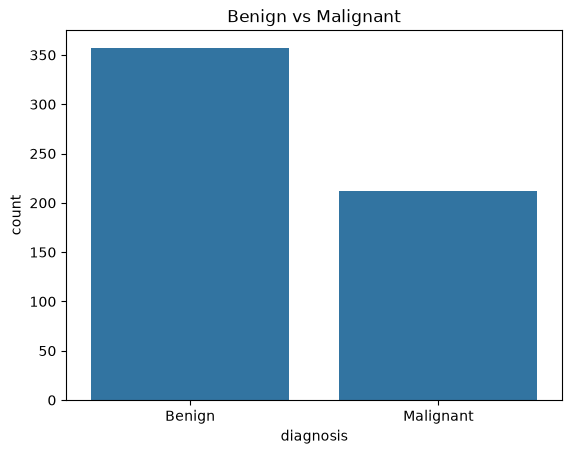

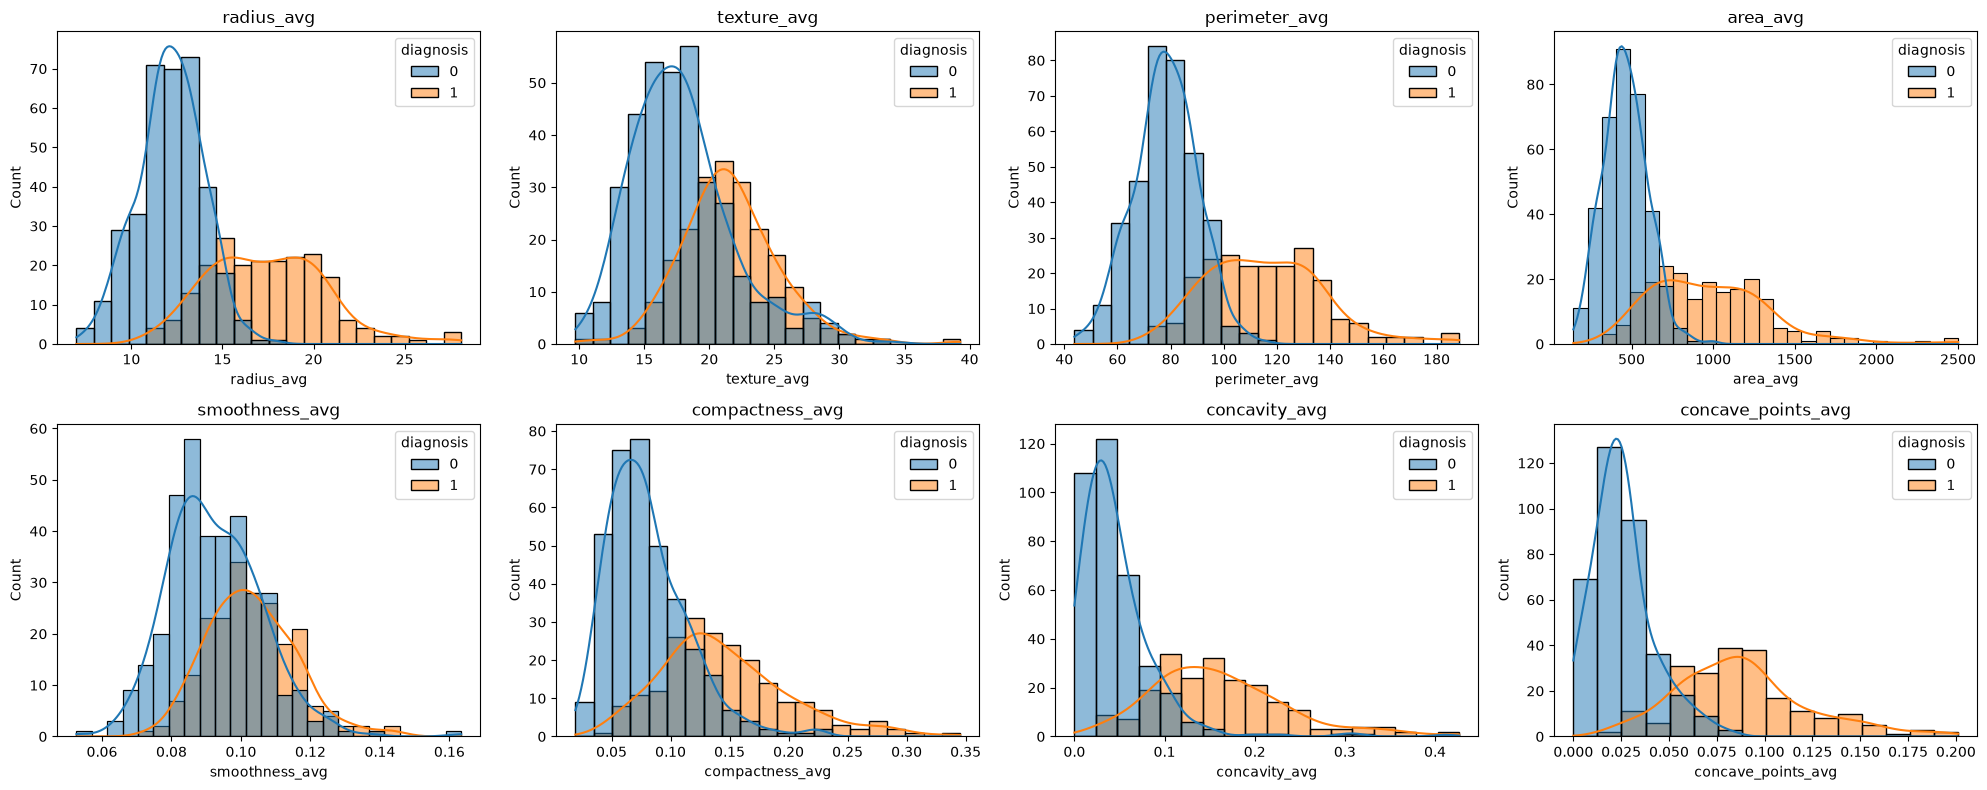

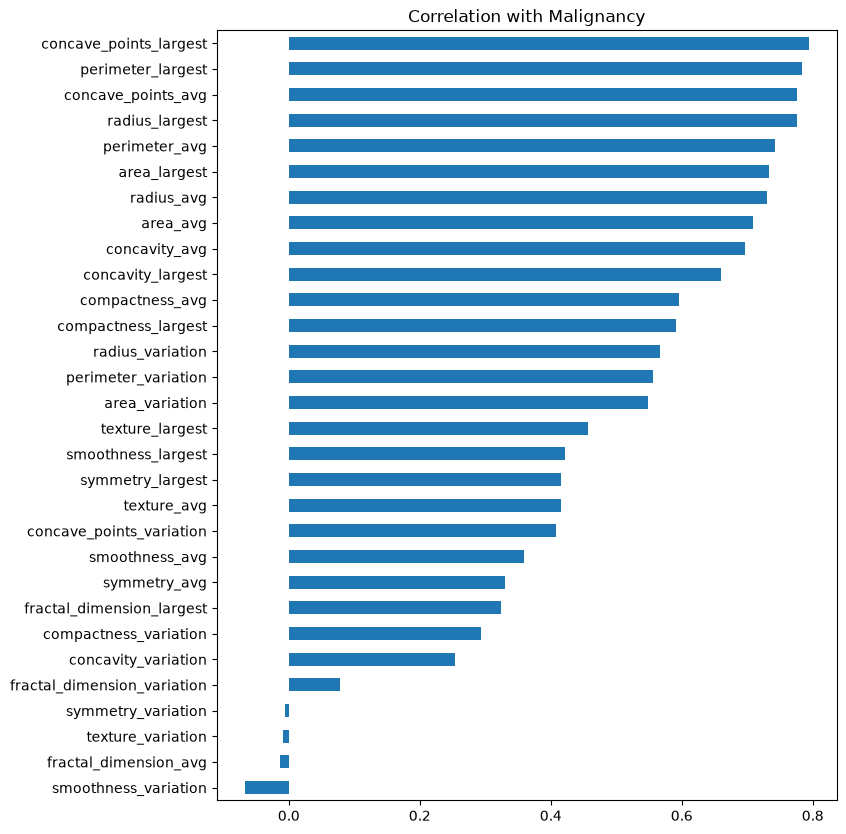

In [5]:
# How many benign vs malignant cases
sns.countplot(x='diagnosis', data=df)
plt.xticks([0,1], ['Benign', 'Malignant'])
plt.title('Benign vs Malignant')
plt.show()

# Compare benign and malignant distributions for each mean feature
avg_cols = [c for c in df.columns if c.endswith('_avg')]

fig, axes = plt.subplots(2, 4, figsize=(20,8))
for ax, col in zip(axes.flat, avg_cols):
  sns.histplot(data=df, x=col, hue='diagnosis', kde=True, ax=ax)
  ax.set_title(col)


plt.tight_layout()
plt.show()


# Which features are most related to the diagnosis
corr = df.drop(columns='diagnosis').corrwith(df['diagnosis']).sort_values()
corr.plot(kind='barh', figsize=(8, 10))
plt.title('Correlation with Malignancy')
plt.show()



## 5. Prepare the Data for Machine Learning

Split the data and scale it so the model can learn fairly.

**Variables:**
- `X`: the inputs (all 30 measurements)
- `y`: the target, what we want to predict (diagnosis)
- `X_train`, `y_train`: 80% of patients, used to **teach** the model
- `X_test`, `y_test`: 20% of patients, kept hidden to **test** the model
- `scaler`: the StandardScaler object
- `X_train_s`, `X_test_s`: the scaled versions of the data

**Functions:**
- `train_test_split()`: randomly splits the data
  - `test_size=0.2`: 20% goes to testing
  - `stratify=y`: keeps the same benign/malignant ratio in both sets
  - `random_state=42`: makes the split the same every time it runs
- `scaler.fit_transform(X_train)`: learns the mean and spread from the training data, then scales it
- `scaler.transform(X_test)`: scales the test data using the **training** values

**Why:**
- The test set acts like new patients, so the model must never see it during training.
- Features have very different ranges (area is in the 1000s, smoothness is about 0.1). Scaling gives each feature mean 0 and standard deviation 1, so no feature dominates just because its numbers are bigger.
- The scaler is fit only on training data to avoid **data leakage**, which happens when test information sneaks into training.

In [6]:
# X = the measurements (inputs), y = the diagnosis (what we predict)

X = df.drop(columns='diagnosis')
y = df['diagnosis']

# Hold back 20% of patients to test the model later
X_train, X_test, y_train, y_test = train_test_split(X, y,
            test_size=0.2, random_state=42, stratify=y)

# Put all features on the same scale (fit only on training data)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


## 6. Train the Models

Teach two different models using the training data, then compare them on the test data.

**Variables:**
- `models`: a dictionary with each model's name and the model itself
- `pred`: the model's predictions for the test patients (0 or 1)

**Functions:**
- `LogisticRegression(max_iter=1000)`: a simple model that draws a boundary between the classes. `max_iter` gives it enough steps to finish learning.
- `RandomForestClassifier()`: many decision trees that vote on the answer
- `model.fit(X_train_s, y_train)`: trains the model
- `model.predict(X_test_s)`: predicts the diagnosis for new patients
- `accuracy_score()`: % of all predictions that were correct
- `recall_score()`: % of actual cancers the model caught

**Why recall matters:** missing a cancer (false negative) is much worse than a false alarm.

In [7]:
# train two models and compare them on the test set

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
}

for name, model in models.items():
  model.fit(X_train_s, y_train)
  pred = model.predict(X_test_s)
  print(f'{name}: accuracy = {accuracy_score(y_test, pred):.3f}, '
          f'recall = {recall_score(y_test, pred):.3f}')




Logistic Regression: accuracy = 0.965, recall = 0.929
Random Forest: accuracy = 0.974, recall = 0.929


## 7. Evaluate the Model

Look at the results of one model in detail.

**Variables:**
- `best`: the model chosen for detailed evaluation

**Functions:**
- `classification_report()`: precision, recall, and F1 for each class
  - **precision**: of the patients predicted malignant, how many really were
  - **recall**: of the patients who really were malignant, how many were caught
  - **F1**: a balance of precision and recall
- `ConfusionMatrixDisplay.from_estimator()`: a grid of correct and wrong predictions
  - top-left = benign correctly predicted
  - bottom-right = malignant correctly predicted
  - bottom-left = **missed cancers** (the worst error)
  - top-right = false alarms

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



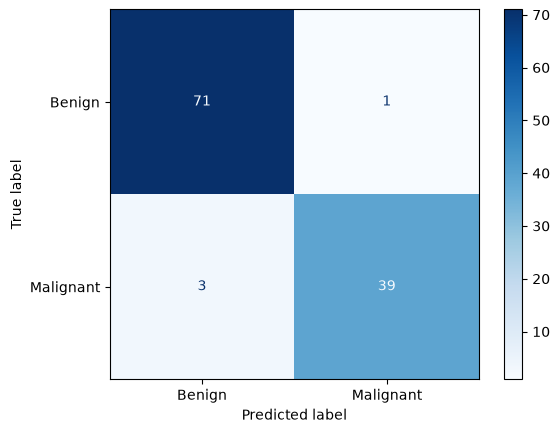

In [8]:
# Detailed results for one model
best = models['Logistic Regression']

print(classification_report(y_test, best.predict(X_test_s),
                            target_names=['Benign', 'Malignant']))

# Confusion matrix: bottom-left = cancers the model missed
ConfusionMatrixDisplay.from_estimator(best, X_test_s, y_test,
                                      display_labels=['Benign', 'Malignant'],
                                      cmap='Blues')

plt.show()


## 8. Make Predictions

Use the trained model like a diagnostic tool on patients it has never seen.

### 8.1 Test patients
Compare the model's predictions with the real diagnoses for 10 test patients.

**Variables:**
- `sample`: the first 10 patients from the test set
- `prob`: the model's probability that each patient is malignant (0 to 1)

**Functions:**
- `.iloc[:10]`: selects the first 10 rows
- `scaler.transform()`: scales the patients the same way as the training data
- `predict_proba()`: returns `[chance benign, chance malignant]` for each patient
- `[:, 1]`: keeps only the malignant chance (`:` = all rows, `1` = second column)
- `.map({0: 'Benign', 1: 'Malignant'})`: turns 0/1 into words
- `display()`: shows a table even when it isn't the last line of the cell
- A probability of **0.5 or more** is predicted malignant

### 8.2 New patients from a file
Predict made-up patients stored in `new_patients.csv`.

**Variables:**
- `new_patients`: the table loaded from the CSV file, one row per patient
- `full`: a complete 30-feature table, starting from typical (median) values
- `result`: the patients plus their probability and prediction

**Functions:**
- `%%writefile new_patients.csv`: creates the CSV file from a code cell
- `pd.read_csv(..., index_col='patient')`: loads the file and uses the patient name as the row label
- `predict_patients()`: our helper function
  - `X.median()`: the middle value of each feature, a "typical" patient
  - features missing from the file are filled with the median
  - `full[X.columns]`: puts the columns in the order the model was trained on
  - returns each patient's malignant probability and prediction

In [9]:
# Predict 10 patient the model has never seen

sample = X_test.iloc[:10]
prob = best.predict_proba(scaler.transform(sample))[:, 1]

display(pd.DataFrame({
    'Actual': y_test.iloc[:10].map({0: 'Benign', 1: 'Malignant'}).values,
    'Predicted': ['Malignant' if p >= 0.5 else 'Benign' for p in prob],
    'Malignant probability': prob.round(3),
}))




,Actual,Predicted,Malignant probability
0,Benign,Benign,0.000
1,Malignant,Malignant,1.000
2,Benign,Benign,0.043
3,Malignant,Malignant,0.576
4,Benign,Malignant,0.509
5,Benign,Benign,0.001
6,Malignant,Malignant,0.762
7,Benign,Benign,0.001
8,Benign,Benign,0.001
9,Benign,Benign,0.011


In [10]:
# Helper: predict

def predict_patients(patients):
  full = pd.DataFrame([X.median()] * len(patients), index=patients.index)
  for col in patients.columns:
    if col in X.columns:
      full[col] = patients[col]

  prob = best.predict_proba(scaler.transform(full[X.columns]))[:, 1]

  result = patients.copy()
  result['malignant probability'] = prob.round(3)
  result['prediction'] = ['Malignant' if p >= 0.5 else 'Benign' for p in prob]
  return result

# Load new patients from the csv file and predict them

new_patients = pd.read_csv('new_patients.csv', index_col='patient')
display(predict_patients(new_patients))




,radius_avg,radius_largest,perimeter_avg,concave_points_largest,malignant probability,prediction
patient,,,,,,
Patient A,12,14,78,0.05,0.019,Benign
Patient B,20,25,130,0.20,0.767,Malignant
Patient C,16,19,105,0.12,0.181,Benign
Patient D,10,11,65,0.02,0.005,Benign


### Prediction Results

**Test patients (8.1):**
- The model correctly predicted **9 out of 10** test patients.
- The one error (row 4) was a **false positive**: a benign tumor predicted as malignant, with a probability of 0.509. This is just above the 0.5 cutoff, so the model was very unsure.
- Rows 3 (0.576) and 6 (0.762) were correct, but with less confidence.

**New patients from the file (8.2):**

| Patient | Malignant probability | Prediction |
|---|---|---|
| A | 1.9% | Benign |
| B | 76.7% | Malignant |
| C | 18.1% | Benign |
| D | 0.5% | Benign |

- Larger tumors (`radius`, `perimeter`) with more inward dents (`concave_points`) get a higher malignant probability.
- Patient C has medium values, so the model is less certain, but it still predicts benign.
- Only 4 features were given. The other 26 were filled with typical (median) values.

**Takeaway:** the probability tells us how confident the model is, not just its final answer. Probabilities close to 0 or 1 mean the model is confident, and values near 0.5 mean it is uncertain. Borderline cases (around 0.4–0.6) should be reviewed by a doctor.